This is the code written to replicate Hidden Markov Model

The necessary imports to ensure the code can run properly
numpy for calculations
sklearn accuracy score ,confusion matrix for metrics
sns for confusion matrix 
matplotlib for graphs
requests,zipfile,io for zipfile

Ensure all dependencies are installed

pip install numpy scikit-learn seaborn matplotlib requests

In [2]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import requests,zipfile,io

This the dataset preprocessing where the vowel dataset is taken it is a sequence of features this data is broken down to enusre that it correctly belongs to the class.

In [ ]:
def dataset_preprocessing(a,train=True):
    seq,label,b1=[],[],[]
    d1=[30]*9 if train else [31,35,88,44,29,24,40,50,29]
    c=np.cumsum(d1)
    i=0

    for l in a:
        l=l.strip()
        if l=="":
            if b1:
                seq.append(np.array(b1))
                label.append(np.searchsorted(c,i))
                b1=[]
                i+=1
        else:
            b1.append(list(map(float,l.split())))
    if b1:
        seq.append(np.array(b1))
        label.append(np.searchsorted(c,i))
    return seq,np.array(label)

This is to get the dataset from the UCI repsoitory

About the dataset it is a Japanese Vowel dataset and has information about how diffrent speaker utter the vowel.

In [4]:
z=zipfile.ZipFile(io.BytesIO(requests.get("https://archive.ics.uci.edu/static/public/128/japanese+vowels.zip").content))
ae_train=z.read("ae.train").decode().splitlines()
ae_test=z.read("ae.test").decode().splitlines()

In [10]:
Xtrain,ytrain=dataset_preprocessing(ae_train,True)
Xtest,ytest=dataset_preprocessing(ae_test,False)

This is to normalize the data.

In [13]:
q=np.vstack(Xtrain)
mean,std=q.mean(0),q.std(0)+1e-9
X_train=[(x-mean)/std for x in Xtrain]
X_test=[(x-mean)/std for x in Xtest]

This is the gaussian probability it help calculate what is the probability of the observation given the Oberavation, mean and covariance.

In [14]:
def b_j(O_t,mu_j,Sigma_j):
    D=len(mu_j)
    Sigma_j = Sigma_j + 1e-3*np.eye(D)
    difference=O_t-mu_j
    inv = np.linalg.inv(Sigma_j)

    number=np.exp(-0.5*difference.T@inv@difference)
    density=np.sqrt((2*np.pi)**D*np.linalg.det(Sigma_j))

    return max(number/density,1e-300)

Inference tasks

Filtering which does the estimation of the current state in real time is done by the forward algorithm which computes how likely is the current state

Prediction is also present in the forward algorithm where I have written the code to project forward without any new obseravation.


This is the forward algorithm this helps compute the past like from the previous state how likely we could reach the current state.

In [15]:
def forward(O,pi,A,mu,Sigma):
    T=len(O)
    N=len(pi)

    alpha=np.zeros((T,N))
    c=np.zeros(T)
    for i in range(N):
        alpha[0,i]=pi[i]*b_j(O[0],mu[i],Sigma[i])
    
    c[0]=alpha[0].sum()+1e-12
    alpha[0]/=c[0]

    
    for t in range(1,T):
        for j in range(N):
            alpha[t,j]=np.sum(alpha[t-1]*A[:,j])*b_j(O[t],mu[j],Sigma[j])

        c[t]=alpha[t].sum()+1e-12
        alpha[t]/=c[t]
    return alpha,c

From the current sequence backwards calculates the probability of future observations.

In [16]:
def backward(O,A,mu,Sigma,c):
    T=len(O)
    N=A.shape[0]
    beta = np.zeros((T,N))
    beta[-1,:]=1.0/c[-1]

    for t in reversed(range(T-1)):
        for i in range(N):
            beta[t,i]=np.sum(A[i,:]*np.array([b_j(O[t+1],mu[j],Sigma[j])*beta[t+1,j] for j in range(N)]))
        beta[t]/=c[t]

    return beta

Baum-Welch learns HMM again and again for each hidden state and improving

The gamma inside the code is smoothing task as it combines both past and future.

In [17]:
class HMM:
    def __init__(self,N,D):
        self.N=N
        self.D=D
        self.pi = np.ones(N)/N
        self.A= np.ones((N,N))/N
        self.mu=np.random.randn(N,D)
        self.Sigma=np.array([np.eye(D) for _ in range(N)])

    def Baum_Welch(self,seq,i1=5):
        for i in range(i1):
            pi_acc=np.zeros(self.N)
            A_acc=np.zeros((self.N,self.N))
            gamma_sum=np.zeros(self.N)
            mu_acc=np.zeros((self.N,self.D))
            Sigma_acc=np.zeros((self.N,self.D,self.D))

            for O in seq:
                T=len(O)
                alpha,c=forward(O,self.pi,self.A,self.mu,self.Sigma)

                beta=backward(O,self.A,self.mu,self.Sigma,c)

                gamma=alpha*beta

                gamma/=gamma.sum(axis=1,keepdims=True)

                pi_acc+=gamma[0]

                for t in range(T-1):
                    xi=np.zeros((self.N,self.N))

                    for i in range(self.N):
                        for j in range(self.N):
                            xi[i,j]=alpha[t,i]*self.A[i,j]*b_j(O[t+1],self.mu[j],self.Sigma[j])*beta[t+1,j]
                    xi/=xi.sum()+1e-12
                    A_acc+=xi
                for j in range(self.N):
                    mu_acc[j]+=np.sum(gamma[:,j][:,None]*O,axis=0)
                    gamma_sum[j]+=gamma[:,j].sum()
                    diff=O-self.mu[j]
                    Sigma_acc[j]+=sum([gamma[t,j]*np.outer(diff[t],diff[t]) for t in range(T)])
            self.pi=(pi_acc+1e-8)/(pi_acc.sum()+1e-8*self.N)
            self.A=(A_acc+1e-8)
            self.A/=self.A.sum(axis=1,keepdims=True)
            self.mu=mu_acc/(gamma_sum[:,None]+1e-8)
            self.Sigma=Sigma_acc/(gamma_sum[:,None,None]+1e-8)
            for j in range(self.N):
                self.Sigma[j]+=1e-3*np.eye(self.D)


            

    def likeh(self,O):
        alpha,c=forward(O,self.pi,self.A,self.mu,self.Sigma) 

        return np.sum(np.log(c+1e-12))

Hidden states is 5 and known and different HMM model for each speaker and trained for 20 iterations and prediction and testing and confusion matrix.

Accuracy:  0.9513513513513514


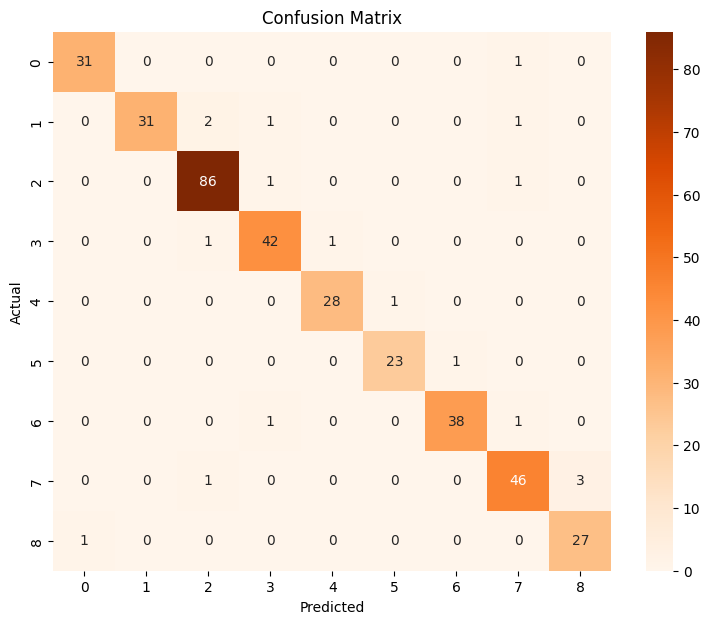

In [18]:
N_states=5
D=X_train[0].shape[1]
models={}
for l in np.unique(ytrain):
    seqs=[X_train[i] for i in range(len(X_train)) if ytrain[i]==l]
    hmm=HMM(N_states,D)
    hmm.Baum_Welch(seqs,i1=20)
    models[l]=hmm

yprediction=[]
for O in X_test:
    scores=[models[l].likeh(O) for l in models]
    yprediction.append(list(models.keys())[np.argmax(scores)])

accuracy=accuracy_score(ytest,yprediction)
print("Accuracy: ",accuracy)

conf=confusion_matrix(ytest,yprediction)

plt.figure(figsize=(9,7))
sns.heatmap(conf,annot=True,fmt="d",cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()